# Projectile Motion in 2D Using Python via Jupyter Notebook
## Standard problem in First-year physics courses
## Goal is to re-create projectile motion using Python 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#First,let's create our grid of points
x = np.linspace(0, 10, 100)
y = np.linspace(0, 10, 100)
X, Y = np.meshgrid(x, y)

In [3]:
# Parameters
v0 = 10. # initial velocity in m/s
theta = 30
v0_x = v0*np.cos(np.radians(theta)) # initial velocity in x direction
v0_y = v0*np.sin(np.radians(theta)) # initial velocity in y direction
x0 = 0.0 # initial x position
y0 = 0.0 # initial y position
g = 9.81 # acceleration due to gravity in m/s^2

In [4]:
pos_x = [x0]
pos_y = [y0]
vel_x = [v0_x]
vel_y = [v0_y]
t0 = 0.
times = [t0]
dt = 0.001
#Update the position and velocity of the projectile until it hits the ground
vel_x.append(vel_x[-1])
vel_y.append(vel_y[-1] - g*dt)
pos_x.append(pos_x[-1] + vel_x[-1] * dt)
pos_y.append(pos_y[-1] + vel_y[-1] * dt)
times.append(times[-1] + dt)
while pos_y[-1] >= 0:
    vel_x.append(vel_x[-1])
    vel_y.append(vel_y[-1] - g*dt)
    pos_x.append(pos_x[-1] + vel_x[-1]*dt)
    pos_y.append(pos_y[-1] + vel_y[-1]*dt)
    times.append(times[-1] + dt)


In [5]:
print(f'Range: {pos_x[-1]:.2f} m')
print(f'Maximum height: {max(pos_y):.2f} m')

Range: 8.82 m
Maximum height: 1.27 m


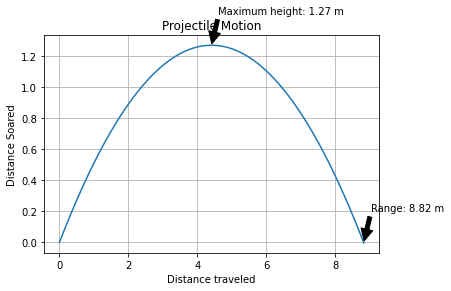

In [6]:
plt.plot(pos_x,pos_y)
plt.annotate(f'Maximum height: {max(pos_y):.2f} m', xy=(pos_x[pos_y.index(max(pos_y))], max(pos_y)), xytext=(pos_x[pos_y.index(max(pos_y))]+0.2, max(pos_y)+0.2),arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate(f'Range: {pos_x[-1]:.2f} m', xy=(pos_x[-1], 0), xytext=(pos_x[-1]+0.2, 0.2),arrowprops=dict(facecolor='black', shrink=0.05))
plt.grid()
plt.xlabel('Distance traveled')
plt.ylabel('Distance Soared')
plt.title('Projectile Motion')
plt.show()

# Above had a constant acceleration in the y direction and no acceleration in the x direction.
# Below we will implement air resistance and see how it affects the projectile motion.
## $F_{drag} = \frac{1}{2} C_d \rho A v^2$ where $C_d$ is the drag coefficient, $\rho$ is the air density, $A$ is the cross-sectional area of the projectile, and $v$ is the velocity of the projectile.
# Now the equations of motion become:
## $m \frac{dv_x}{dt} = -\frac{1}{2} C_d \rho A v v_x$ and $m \frac{dv_y}{dt} = -mg - \frac{1}{2} C_d \rho A v v_y$
# We can solve these equations using numerical methods such as Euler's method or Runge-Kutta method. Below is an implementation using Euler's method.

In [12]:
pos2_x = [x0]
pos2_y = [y0]
vel2_x = [v0_x]
vel2_y = [v0_y]
t0 = 0.
times2 = [t0]
Cd = 0.47 # drag coefficient for a sphere
rho = 1.225 # air density in kg/m^3
A = np.pi * (0.5)**2 # cross-sectional area of the projectile in m^2
m = 1.0 # mass of the projectile in kg

In [13]:
# Create a function to calculate the total force 
def force(vel_x, vel_y):
    v = np.sqrt(vel_x**2 + vel_y**2)
    F_drag_x = -0.5 * Cd * rho * A * v * vel_x
    F_drag_y = -0.5 * Cd * rho * A * v * vel_y
    F_gravity_y = -m * g
    return F_drag_x, F_drag_y + F_gravity_y

In [14]:
# Update the position and velocity of the projectile until it hits the ground
F_x, F_y = force(vel2_x[-1], vel2_y[-1])
vel2_x.append(vel2_x[-1] + F_x/m*dt)
vel2_y.append(vel2_y[-1] + F_y/m*dt)
pos2_x.append(pos2_x[-1] + vel2_x[-1] * dt)
pos2_y.append(pos2_y[-1] + vel2_y[-1] * dt)
times2.append(times2[-1] + dt)
while pos2_y[-1] >= 0:
    F_x, F_y = force(vel2_x[-1], vel2_y[-1])
    vel2_x.append(vel2_x[-1] + F_x/m*dt)
    vel2_y.append(vel2_y[-1] + F_y/m*dt)
    pos2_x.append(pos2_x[-1] + vel2_x[-1]*dt)
    pos2_y.append(pos2_y[-1] + vel2_y[-1]*dt)
    times2.append(times2[-1] + dt)

In [15]:
print(f'Range: {pos2_x[-1]:.2f} m')
print(f'Maximum height: {max(pos2_y):.2f} m')

Range: 4.05 m
Maximum height: 0.80 m


In [16]:
print(f'The difference between the range with and without air resistance is {abs(pos_x[-1] - pos2_x[-1]):.2f} m')
print(f'The difference between the maximum height with and without air resistance is {abs(max(pos_y) - max(pos2_y)):.2f} m')

The difference between the range with and without air resistance is 4.77 m
The difference between the maximum height with and without air resistance is 0.47 m


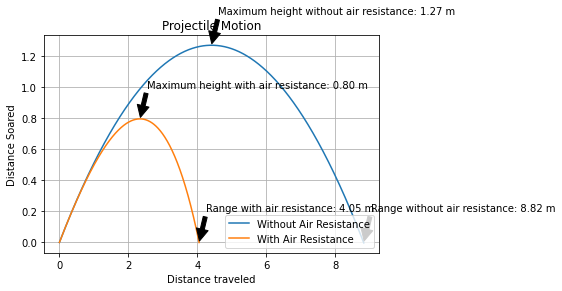

In [18]:
plt.plot(pos_x,pos_y)
plt.plot(pos2_x,pos2_y)
plt.annotate(f'Maximum height without air resistance: {max(pos_y):.2f} m', xy=(pos_x[pos_y.index(max(pos_y))], max(pos_y)), xytext=(pos_x[pos_y.index(max(pos_y))]+0.2, max(pos_y)+0.2),arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate(f'Maximum height with air resistance: {max(pos2_y):.2f} m', xy=(pos2_x[pos2_y.index(max(pos2_y))], max(pos2_y)), xytext=(pos2_x[pos2_y.index(max(pos2_y))]+0.2, max(pos2_y)+0.2),arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate(f'Range without air resistance: {pos_x[-1]:.2f} m', xy=(pos_x[-1], 0), xytext=(pos_x[-1]+0.2, 0.2),arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate(f'Range with air resistance: {pos2_x[-1]:.2f} m', xy=(pos2_x[-1], 0), xytext=(pos2_x[-1]+0.2, 0.2),arrowprops=dict(facecolor='black', shrink=0.05))
plt.grid()
plt.xlabel('Distance traveled')
plt.ylabel('Distance Soared')
plt.title('Projectile Motion')
plt.legend(['Without Air Resistance', 'With Air Resistance'])
plt.show()

## The trajectory of the projectile motion with air resistance depends on the parameters of the object and its initial velocity.
## Tuning such parameters can lead to varying trajectories.
## 